In [1]:
from google.colab import files
uploaded = files.upload()

Saving healthcare_encoded.csv to healthcare_encoded.csv


In [2]:
import pandas as pd

df = pd.read_csv("healthcare_encoded.csv")
df.head()

,Name,Age,Date of Admission,Doctor,Hospital,Billing Amount,Room Number,Discharge Date,Gender_Male,Blood Type_A-,...,Insurance Provider_Medicare,Insurance Provider_UnitedHealthcare,Admission Type_Emergency,Admission Type_Urgent,Medication_Ibuprofen,Medication_Lipitor,Medication_Paracetamol,Medication_Penicillin,Test Results_Inconclusive,Test Results_Normal
0,Tiffany Ramirez,81,2022-11-17,Patrick Parker,Wallace-Hamilton,37490.983364,146,2022-12-01,False,False,...,True,False,False,False,False,False,False,False,True,False
1,Ruben Burns,35,2023-06-01,Diane Jackson,"Burke, Griffin and Cooper",47304.064845,404,2023-06-15,True,False,...,False,True,True,False,False,True,False,False,False,True
2,Chad Byrd,61,2019-01-09,Paul Baker,Walton LLC,36874.896997,292,2019-02-08,True,False,...,True,False,True,False,False,True,False,False,False,True
3,Antonio Frederick,49,2020-05-02,Brian Chandler,Garcia Ltd,23303.322092,480,2020-05-03,True,False,...,True,False,False,True,False,False,False,True,False,False
4,Mrs. Brandy Flowers,51,2021-07-09,Dustin Griffin,"Jones, Brown and Murray",18086.344184,477,2021-08-02,True,False,...,False,True,False,True,False,False,True,False,False,True


In [3]:
y = df["Billing Amount"]
X = df.drop("Billing Amount", axis=1)

In [4]:
import statsmodels.api as sm

X = sm.add_constant(X)

In [6]:
import pandas as pd
import statsmodels.api as sm


df = pd.read_csv("healthcare_encoded.csv")


y = df["Billing Amount"]


X = df.drop("Billing Amount", axis=1)


X = X.drop(columns=["Name", "Doctor", "Hospital", "Date of Admission", "Discharge Date"])


X = X.apply(lambda col: col.astype(int) if col.dtype == 'bool' else col)


X = sm.add_constant(X)


modelo = sm.OLS(y, X).fit()


print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:         Billing Amount   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     1.679
Date:                Tue, 14 Apr 2026   Prob (F-statistic):             0.0152
Time:                        16:41:45   Log-Likelihood:            -1.0968e+05
No. Observations:               10000   AIC:                         2.194e+05
Df Residuals:                    9972   BIC:                         2.196e+05
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
co

In [8]:
import statsmodels.api as sm

def backward_elimination(X, y, threshold=0.10):
    X = sm.add_constant(X)

    while True:
        modelo = sm.OLS(y, X).fit()
        p_values = modelo.pvalues

        max_p = p_values.max()

        if max_p > threshold:
            col_to_drop = p_values.idxmax()
            print(f"Eliminando: {col_to_drop} (p={max_p})")
            X = X.drop(columns=[col_to_drop])
        else:
            break

    return X, modelo

X_opt, modelo_final = backward_elimination(X, y, threshold=0.10)

print(modelo_final.summary())

Eliminando: Medical Condition_Hypertension (p=0.9874592999709031)
Eliminando: Gender_Male (p=0.838577813824303)
Eliminando: Admission Type_Urgent (p=0.8008715642565638)
Eliminando: Insurance Provider_Cigna (p=0.7092202486596049)
Eliminando: Insurance Provider_Blue Cross (p=0.7851069237729729)
Eliminando: Blood Type_O+ (p=0.6572125444127831)
Eliminando: Test Results_Inconclusive (p=0.6461856194124784)
Eliminando: Medical Condition_Asthma (p=0.6378963237480801)
Eliminando: Room Number (p=0.5683618841953673)
Eliminando: Medication_Lipitor (p=0.4867062437924231)
Eliminando: Medical Condition_Cancer (p=0.43436852123435754)
Eliminando: Insurance Provider_UnitedHealthcare (p=0.42414272967804123)
Eliminando: Age (p=0.3611051463257883)
Eliminando: Test Results_Normal (p=0.34640547722816883)
Eliminando: Blood Type_AB- (p=0.33365819091437243)
Eliminando: Blood Type_B+ (p=0.3475988223824784)
Eliminando: Blood Type_O- (p=0.35824930108502284)
Eliminando: Blood Type_B- (p=0.3809950084293462)
Eliminan

In [9]:
import pandas as pd
import numpy as np
import statsmodels.api as sm


df = pd.read_csv("healthcare_encoded.csv")


y = np.log(df["Billing Amount"])


X = df.drop("Billing Amount", axis=1)


columnas_a_eliminar = ["Name", "Doctor", "Hospital", "Date of Admission", "Discharge Date"]
X = X.drop(columns=columnas_a_eliminar, errors="ignore")


X = X.apply(lambda col: col.astype(int) if col.dtype == 'bool' else col)


X = X.apply(pd.to_numeric, errors="coerce")


data_modelo = pd.concat([X, y], axis=1).dropna()
X = data_modelo.drop(columns=["Billing Amount"])
y = data_modelo["Billing Amount"]


variables_protegidas = ["Age", "Room Number"]

def backward_elimination(X, y, threshold=0.10, keep_vars=None):
    if keep_vars is None:
        keep_vars = []

    X_model = X.copy()
    X_model = sm.add_constant(X_model, has_constant="add")

    while True:
        modelo = sm.OLS(y, X_model).fit()
        p_values = modelo.pvalues.drop("const", errors="ignore")


        candidatos = p_values.drop(labels=[v for v in keep_vars if v in p_values.index], errors="ignore")

        if len(candidatos) == 0:
            break

        max_p = candidatos.max()
        col_to_drop = candidatos.idxmax()

        if max_p > threshold:
            print(f"Eliminando: {col_to_drop} (p={max_p})")
            X_model = X_model.drop(columns=[col_to_drop])
        else:
            break

    modelo_final = sm.OLS(y, X_model).fit()
    return X_model, modelo_final

X_opt, modelo_final = backward_elimination(
    X,
    y,
    threshold=0.10,
    keep_vars=variables_protegidas
)

print(modelo_final.summary())


Eliminando: Gender_Male (p=0.9781849229830828)
Eliminando: Blood Type_O+ (p=0.9607382959965685)
Eliminando: Medical Condition_Cancer (p=0.8954870219532713)
Eliminando: Insurance Provider_Cigna (p=0.8073710687713316)
Eliminando: Test Results_Normal (p=0.8004754300349758)
Eliminando: Insurance Provider_Blue Cross (p=0.7224329794986928)
Eliminando: Medication_Ibuprofen (p=0.6659416387421575)
Eliminando: Medical Condition_Hypertension (p=0.578895014652095)
Eliminando: Insurance Provider_UnitedHealthcare (p=0.5391877444707305)
Eliminando: Medical Condition_Asthma (p=0.5356971734989224)
Eliminando: Test Results_Inconclusive (p=0.4563218880700344)
Eliminando: Blood Type_AB- (p=0.34572272852935737)
Eliminando: Blood Type_B- (p=0.48298594157086816)
Eliminando: Blood Type_B+ (p=0.509023698627699)
Eliminando: Blood Type_O- (p=0.5318037439063937)
Eliminando: Blood Type_AB+ (p=0.534250982205658)
Eliminando: Medical Condition_Obesity (p=0.292262795468477)
Eliminando: Medication_Lipitor (p=0.29204319

In [10]:
import pandas as pd
import numpy as np
import statsmodels.api as sm


df = pd.read_csv("healthcare_encoded.csv")


df["Age_group"] = pd.cut(df["Age"], bins=[0, 30, 60, 100])


df = pd.get_dummies(df, columns=["Age_group"], drop_first=True)


y = np.log(df["Billing Amount"])


X = df.drop("Billing Amount", axis=1)



columnas_a_eliminar = [
    "Name",
    "Doctor",
    "Hospital",
    "Date of Admission",
    "Discharge Date",
    "Room Number"

]
X = X.drop(columns=columnas_a_eliminar, errors="ignore")



X = X.apply(lambda col: col.astype(int) if col.dtype == "bool" else col)



X = X.apply(pd.to_numeric, errors="coerce")



data_modelo = pd.concat([X, y], axis=1).dropna()
X = data_modelo.drop(columns=["Billing Amount"])
y = data_modelo["Billing Amount"]



variables_protegidas = ["Age"]
for col in X.columns:
    if "Age_group" in col:
        variables_protegidas.append(col)

def backward_elimination(X, y, threshold=0.10, keep_vars=None):
    if keep_vars is None:
        keep_vars = []

    X_model = X.copy()
    X_model = sm.add_constant(X_model, has_constant="add")

    while True:
        modelo = sm.OLS(y, X_model).fit()
        p_values = modelo.pvalues.drop("const", errors="ignore")

        candidatos = p_values.drop(
            labels=[v for v in keep_vars if v in p_values.index],
            errors="ignore"
        )

        if len(candidatos) == 0:
            break

        max_p = candidatos.max()
        col_to_drop = candidatos.idxmax()

        if max_p > threshold:
            print(f"Eliminando: {col_to_drop} (p={max_p})")
            X_model = X_model.drop(columns=[col_to_drop])
        else:
            break

    modelo_final = sm.OLS(y, X_model).fit()
    return X_model, modelo_final


X_opt, modelo_final = backward_elimination(
    X,
    y,
    threshold=0.10,
    keep_vars=variables_protegidas
)


print(modelo_final.summary())


print("\nVariables finales del modelo:")
print(X_opt.columns.tolist())

Eliminando: Gender_Male (p=0.978168489649787)
Eliminando: Blood Type_O+ (p=0.9621316607281349)
Eliminando: Medical Condition_Cancer (p=0.8960770781428077)
Eliminando: Insurance Provider_Cigna (p=0.8050449243911597)
Eliminando: Test Results_Normal (p=0.7991254630820889)
Eliminando: Insurance Provider_Blue Cross (p=0.7211577638935016)
Eliminando: Medication_Ibuprofen (p=0.662583254854388)
Eliminando: Medical Condition_Hypertension (p=0.58524741566032)
Eliminando: Insurance Provider_UnitedHealthcare (p=0.5364724455100687)
Eliminando: Medical Condition_Asthma (p=0.5360257300446767)
Eliminando: Test Results_Inconclusive (p=0.45233864938560775)
Eliminando: Blood Type_AB- (p=0.34277076011962127)
Eliminando: Blood Type_B- (p=0.4808228045684124)
Eliminando: Blood Type_B+ (p=0.5137635189651583)
Eliminando: Blood Type_O- (p=0.5246251329058216)
Eliminando: Blood Type_AB+ (p=0.5251739578926378)
Eliminando: Medical Condition_Obesity (p=0.29453978536949516)
Eliminando: Medication_Lipitor (p=0.2906918

In [11]:
import pandas as pd
import numpy as np
import statsmodels.api as sm


df = pd.read_csv("healthcare_encoded.csv")


df["Age_group"] = pd.cut(df["Age"], bins=[0, 30, 60, 100])


df = pd.get_dummies(df, columns=["Age_group"], drop_first=True)


y = np.log(df["Billing Amount"])


X = df.drop("Billing Amount", axis=1)


columnas_a_eliminar = [
    "Name",
    "Doctor",
    "Hospital",
    "Date of Admission",
    "Discharge Date",
    "Room Number",
    "Age"
]
X = X.drop(columns=columnas_a_eliminar, errors="ignore")


X = X.apply(lambda col: col.astype(int) if col.dtype == "bool" else col)


X = X.apply(pd.to_numeric, errors="coerce")


data_modelo = pd.concat([X, y], axis=1).dropna()
X = data_modelo.drop(columns=["Billing Amount"])
y = data_modelo["Billing Amount"]


variables_protegidas = [col for col in X.columns if "Age_group" in col]

def backward_elimination(X, y, threshold=0.10, keep_vars=None):
    if keep_vars is None:
        keep_vars = []

    X_model = X.copy()
    X_model = sm.add_constant(X_model, has_constant="add")

    while True:
        modelo = sm.OLS(y, X_model).fit()
        p_values = modelo.pvalues.drop("const", errors="ignore")

        candidatos = p_values.drop(
            labels=[v for v in keep_vars if v in p_values.index],
            errors="ignore"
        )

        if len(candidatos) == 0:
            break

        max_p = candidatos.max()
        col_to_drop = candidatos.idxmax()

        if max_p > threshold:
            print(f"Eliminando: {col_to_drop} (p={max_p})")
            X_model = X_model.drop(columns=[col_to_drop])
        else:
            break

    modelo_final = sm.OLS(y, X_model).fit()
    return X_model, modelo_final


X_opt, modelo_final = backward_elimination(
    X,
    y,
    threshold=0.10,
    keep_vars=variables_protegidas
)


print(modelo_final.summary())


print("\nVariables finales del modelo:")
print(X_opt.columns.tolist())

Eliminando: Gender_Male (p=0.9794677841459808)
Eliminando: Blood Type_O+ (p=0.9652648846188637)
Eliminando: Medical Condition_Cancer (p=0.89374863973645)
Eliminando: Insurance Provider_Cigna (p=0.8069697843236359)
Eliminando: Test Results_Normal (p=0.7988670464138978)
Eliminando: Insurance Provider_Blue Cross (p=0.7206100346995868)
Eliminando: Medication_Ibuprofen (p=0.6653436710794027)
Eliminando: Medical Condition_Hypertension (p=0.5800070191085518)
Eliminando: Insurance Provider_UnitedHealthcare (p=0.5399845873772284)
Eliminando: Medical Condition_Asthma (p=0.5359884899823377)
Eliminando: Test Results_Inconclusive (p=0.454843351597212)
Eliminando: Blood Type_AB- (p=0.3434163557933243)
Eliminando: Blood Type_B- (p=0.482688804202311)
Eliminando: Blood Type_B+ (p=0.5104707374686597)
Eliminando: Blood Type_O- (p=0.5278623444950057)
Eliminando: Blood Type_AB+ (p=0.5303142576394173)
Eliminando: Medical Condition_Obesity (p=0.2923204580126516)
Eliminando: Medication_Lipitor (p=0.2918032356

El gráfico de valores reales frente a valores predichos permite evaluar la capacidad del modelo para aproximarse a los datos observados. En un modelo ideal, los puntos deberían alinearse a lo largo de una línea diagonal, lo que indicaría que las predicciones coinciden con los valores reales.

En este caso, se observa una dispersión considerable de los puntos, sin una tendencia clara hacia la diagonal. Esto indica que el modelo no logra predecir con precisión los valores del costo médico. Este comportamiento es coherente con el bajo valor del coeficiente de determinación (R² ≈ 0.002), lo que sugiere que las variables incluidas explican una proporción muy reducida de la variabilidad del costo.

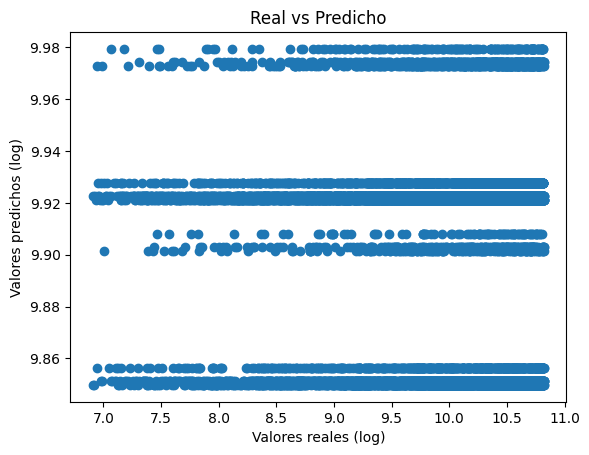

In [12]:
import matplotlib.pyplot as plt


y_pred = modelo_final.predict(X_opt)

plt.scatter(y, y_pred)
plt.xlabel("Valores reales (log)")
plt.ylabel("Valores predichos (log)")
plt.title("Real vs Predicho")
plt.show()

El gráfico de valores reales vs predichos permite evaluar la capacidad del modelo para aproximarse a los datos observados. Idealmente, los puntos deberían alinearse sobre una línea diagonal, lo que indicaría que las predicciones coinciden con los valores reales.

Sin embargo, en este caso se observa una dispersión considerable de los puntos, lo que indica que el modelo no logra capturar adecuadamente la variabilidad del costo médico. Esto es consistente con el bajo valor del coeficiente de determinación (R²), evidenciando una baja capacidad predictiva.

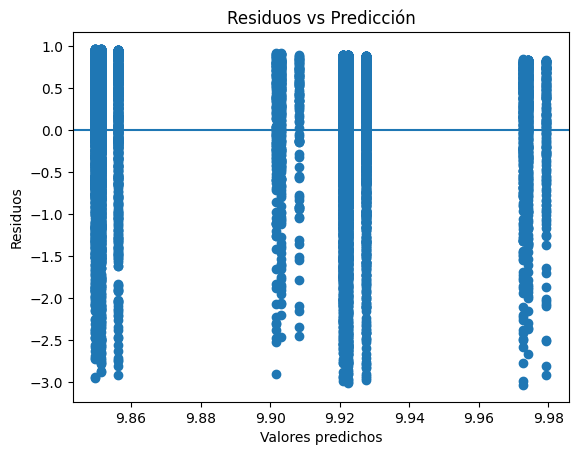

In [13]:
residuos = y - y_pred

plt.scatter(y_pred, residuos)
plt.axhline(y=0)
plt.xlabel("Valores predichos")
plt.ylabel("Residuos")
plt.title("Residuos vs Predicción")
plt.show()

El gráfico de residuos permite analizar si los errores del modelo se distribuyen de manera aleatoria. En un modelo adecuado, los residuos deberían dispersarse de forma uniforme alrededor de cero, sin patrones visibles.

En este caso, aunque los residuos se distribuyen alrededor de la línea horizontal, se observa una dispersión amplia, lo que indica que el modelo presenta errores considerables en sus predicciones. Esto sugiere que las variables utilizadas no son suficientes para explicar el comportamiento del costo médico.

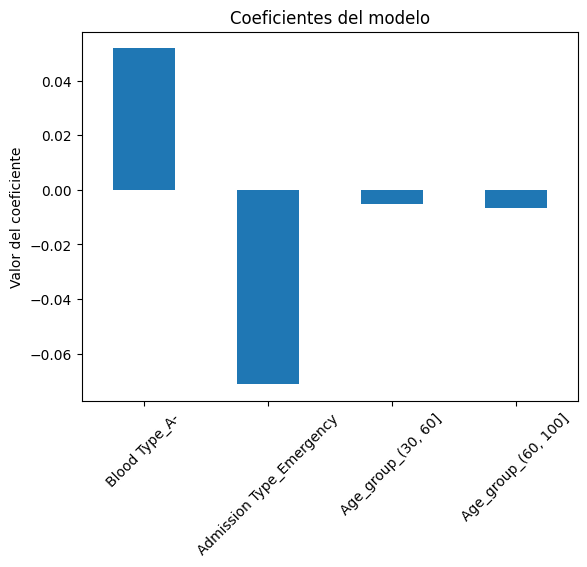

In [14]:
coef = modelo_final.params.drop("const")

coef.plot(kind="bar")
plt.title("Coeficientes del modelo")
plt.ylabel("Valor del coeficiente")
plt.xticks(rotation=45)
plt.show()

El gráfico de coeficientes muestra la influencia de cada variable independiente sobre la variable dependiente. Los coeficientes positivos indican un aumento en el costo médico, mientras que los negativos indican una disminución.

En este modelo, se observa que variables como el tipo de admisión de emergencia presentan un efecto significativo, mientras que otras variables tienen un impacto menor o no significativo. Esto permite identificar cuáles factores tienen mayor relevancia dentro del modelo.